<a href="https://colab.research.google.com/github/nananana25/MSI140/blob/main/MIS140_W03_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Welcome to MIS140 Week 03


# Exploratory Data Analysis


# 🏆 Learning Objectives
By the end of this lab, you will be able to:
- Perform univariate analysis for numerical and categorical variables.
- Generate summary statistics and visualize distributions.

### **Melbourne Housing Market Dataset: Business Insights**  

This dataset provides real estate transaction data for Melbourne, helping to analyze market trends, price fluctuations, and buyer opportunities. It can be used to answer business and economic questions about Melbourne’s housing market.  

### **Data Dictionary for Selected Columns**

| Column         | Description |
|---------------|------------|
| **Suburb** | Name of the suburb where the property is located. |
| **Address** | Full address of the property. |
| **Rooms** | Total number of rooms in the property. |
| **Type** | Property type: <br> - `h` (house, cottage, villa, semi, terrace) <br> - `u` (unit, duplex) <br> - `t` (townhouse) <br> - `dev site` (development site) <br> - `o res` (other residential) |
| **Price** | Sale price of the property in Australian dollars. |
| **Method** | Sale method: e.g., `S` (sold), `SP` (sold prior), `PI` (passed in), `W` (withdrawn), `VB` (vendor bid). |
| **SellerG** | Name of the real estate agency selling the property. |
| **Date** | Date the property was sold. |
| **Postcode** | Postal code of the property's location. |
| **Regionname** | Broad geographic region (e.g., West, North West, North East). |
| **Propertycount** | Total number of properties in the suburb. |
| **Distance** | Distance from the CBD in kilometres. |
| **CouncilArea** | Local governing council for the suburb. |

The dataset **"Melbourne Housing Market"** is available on **Kaggle**:  
**[Melbourne Housing Market Dataset – Kaggle](https://www.kaggle.com/datasets/anthonypino/melbourne-housing-market/data)**  



---

# Pair Programming EDA Journey — *Melbourne Housing Dataset*

| Stage                                       | Business Focus                              | Questions                                                                                                                                                                                                               | Discussion                                                                                                                                                                                                     |
| :------------------------------------------ | :------------------------------------------ | :---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | :-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **1. Data Inspection**                   | Understand structure and quality            | - What types of variables are in the dataset? <br> - Which columns are complete vs. have missing data? <br> - Are data types appropriate?                                                                               | - Does anything look suspicious in `df.info()` or `df.describe()`? <br> - Which columns will likely need cleaning? <br> - Any duplicated or irrelevant fields?                                                        |
| **2. Data Cleaning**                     | Ensure usable and consistent data           | - Which features have missing or inconsistent values? <br> - How should we treat `BuildingArea`, `YearBuilt`, `Price` missingness? <br> - Should any outliers be removed, capped, or retained?                          | - Is it safe to impute missing values? On what basis? <br> - How might removal or transformation affect downstream analysis? <br> - When do outliers represent business insight vs. data error?                       |
| **3. Univariate Analysis**               | Understand each feature's distribution      | - What is the typical distribution of `Price`, `Landsize`, `Distance`, etc.? <br> - Are there extreme values or skewed distributions? <br> - Which suburbs have the highest property counts?                            | - What does the shape of the distribution suggest (e.g. skewed, multimodal)? <br> - How do measures of central tendency and spread help us interpret housing supply or demand?                                        |
| **4. Interpretation & Business Insight** | Translate patterns into strategy            | - When and where did the housing market cool? <br> - What early indicators signalled the shift? <br> - Should one invest in units, townhouses, or detached homes in 2025?                                               | - Which insights are actionable for a home buyer, investor, or policymaker? <br> - What recommendations would you give based on current and historical trends? <br> - Are patterns likely to persist or change? Why?  |

---

### Pair Roles and Discussions

* **Driver**: Write code to load, inspect, filter, summarise, and visualise.
* **Navigator**: Ask guiding questions:

  * *“Why this variable?”*
  * *“What are we assuming?”*
  * *“What’s the business impact?”*
* **Both**: Reflect on:

  * *“What would we recommend to a buyer, seller, or agent based on this?”*

---

# Load the Dataset

## Import Libaries

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Mount Google Drive to Colab

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Load Your Data

In [9]:
# Replace with the correct file path from your Google Drive
file_path = '/content/Melbourne_housing_FULL.csv'

# Load the dataset into a pandas DataFrame
df = pd.read_csv(file_path)

In [10]:
url = 'https://raw.githubusercontent.com/ABAL-DU/MIS140_Resources/refs/heads/main/MELBOURNE_HOUSE_PRICES_LESS.csv'
# url = 'https://raw.githubusercontent.com/ABAL-DU/MIS140_Resources/refs/heads/main/Melbourne_housing_FULL.csv'
# Load the dataset into a pandas DataFrame
df = pd.read_csv(url)

In [11]:
df

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Postcode,Regionname,Propertycount,Distance,CouncilArea
0,Abbotsford,49 Lithgow St,3,h,1490000.0,S,Jellis,1/04/2017,3067,Northern Metropolitan,4019,3.0,Yarra City Council
1,Abbotsford,59A Turner St,3,h,1220000.0,S,Marshall,1/04/2017,3067,Northern Metropolitan,4019,3.0,Yarra City Council
2,Abbotsford,119B Yarra St,3,h,1420000.0,S,Nelson,1/04/2017,3067,Northern Metropolitan,4019,3.0,Yarra City Council
3,Aberfeldie,68 Vida St,3,h,1515000.0,S,Barry,1/04/2017,3040,Western Metropolitan,1543,7.5,Moonee Valley City Council
4,Airport West,92 Clydesdale Rd,2,h,670000.0,S,Nelson,1/04/2017,3042,Western Metropolitan,3464,10.4,Moonee Valley City Council
...,...,...,...,...,...,...,...,...,...,...,...,...,...
63018,Roxburgh Park,3 Carr Pl,3,h,566000.0,S,Raine,31/03/2018,3064,Northern Metropolitan,5833,20.6,Hume City Council
63019,Roxburgh Park,9 Parker Ct,3,h,500000.0,S,Raine,31/03/2018,3064,Northern Metropolitan,5833,20.6,Hume City Council
63020,Roxburgh Park,5 Parkinson Wy,3,h,545000.0,S,Raine,31/03/2018,3064,Northern Metropolitan,5833,20.6,Hume City Council
63021,Thomastown,3/1 Travers St,3,u,NaN,PI,Barry,31/03/2018,3074,Northern Metropolitan,7955,15.3,Whittlesea City Council


# Inspect Data

Before any analysis, it is essential to understand the structure and quality of the dataset. A quick and informative first step is to run `df.info()`.

**What to note in `df.info()`:**

* **Row count and column count**: Confirms dataset size and whether expected variables are present.
* **Column names and data types**: Helps identify:

  * Categorical vs numerical variables
  * Unexpected data types (e.g. numbers stored as `object`)
* **Non-null counts**: Reveals missing values and potential data quality issues.
* **Memory usage**: Useful for large datasets—may require optimisation.

**Tip**: Combine this with `df.head()` and `df.describe()` to form a comprehensive understanding of data shape, types, and initial distribution patterns.


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63023 entries, 0 to 63022
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         63023 non-null  object 
 1   Address        63023 non-null  object 
 2   Rooms          63023 non-null  int64  
 3   Type           63023 non-null  object 
 4   Price          48433 non-null  float64
 5   Method         63023 non-null  object 
 6   SellerG        63023 non-null  object 
 7   Date           63023 non-null  object 
 8   Postcode       63023 non-null  int64  
 9   Regionname     63023 non-null  object 
 10  Propertycount  63023 non-null  int64  
 11  Distance       63023 non-null  float64
 12  CouncilArea    63023 non-null  object 
dtypes: float64(2), int64(3), object(8)
memory usage: 6.3+ MB


In [13]:
df.isna().sum()

,0
Suburb,0
Address,0
Rooms,0
Type,0
Price,14590
Method,0
SellerG,0
Date,0
Postcode,0
Regionname,0


# Clean data

To do:
- Convert `Date` Dtype
- Handle `Price` missing values

In [14]:
# Convert df['Date'] to datetime64[ns]
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y', errors='raise')

In [15]:
# Drop rows where 'Price' is missing
df = df.dropna(subset=['Price'])

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48433 entries, 0 to 63020
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Suburb         48433 non-null  object        
 1   Address        48433 non-null  object        
 2   Rooms          48433 non-null  int64         
 3   Type           48433 non-null  object        
 4   Price          48433 non-null  float64       
 5   Method         48433 non-null  object        
 6   SellerG        48433 non-null  object        
 7   Date           48433 non-null  datetime64[ns]
 8   Postcode       48433 non-null  int64         
 9   Regionname     48433 non-null  object        
 10  Propertycount  48433 non-null  int64         
 11  Distance       48433 non-null  float64       
 12  CouncilArea    48433 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(3), object(7)
memory usage: 5.2+ MB


In [17]:
# Verify missing values are removed
df.isna().sum()

,0
Suburb,0
Address,0
Rooms,0
Type,0
Price,0
Method,0
SellerG,0
Date,0
Postcode,0
Regionname,0


# Univariate Analysis


**Univariate analysis** examines one variable at a time to understand its distribution, central tendency, and spread.

**Why it matters:**
It helps detect patterns, outliers, skewness, and data quality issues—forming the foundation for deeper analysis.

**What to explore:**

* **Data type**: Categorical or numerical
* **Key statistics**:

  * For numerical: mean, median, mode, min, max, standard deviation
  * For categorical: frequency counts and proportions
* **Distribution shape**: Symmetric, skewed, uniform, bimodal, etc.
* **Outliers and missing values**

**Tools**:
Use `value_counts()`, `describe()`, histograms, box plots, or bar charts to summarise and visualise the variable.


## Numerical variables

### Descriptive statistics

Running `df.describe()` provides a quick statistical summary of numerical (and optionally categorical) variables.

**What’s helpful in `df.describe()`:**

* **count**: Number of non-missing values — reveals missing data issues.
* **mean**: Average — useful for measuring central tendency.
* **std**: Standard deviation — indicates the spread or variability.
* **min / max**: Range of values — helps spot outliers or extreme values.
* **25% / 50% / 75% (quartiles)**:

  * Show data distribution.
  * The **50% (median)** is especially useful if the mean is affected by skew or outliers.
* **IQR (Interquartile Range)**: Can be inferred from 75% – 25%; useful for detecting outliers.

**Tip**: Use alongside visual tools like histograms and box plots for a better understanding of variable distribution.


In [18]:
# df.describe() no scientific number
pd.options.display.float_format = '{:.2f}'.format
df.describe()

,Rooms,Price,Date,Postcode,Propertycount,Distance
count,48433.00,48433.00,48433,48433.00,48433.00,48433.00
mean,3.07,997898.24,2017-07-31 10:08:52.645097216,3123.21,7566.40,12.70
min,1.00,85000.00,2016-01-28 00:00:00,3000.00,39.00,0.00
25%,2.00,620000.00,2016-12-03 00:00:00,3051.00,4280.00,7.00
50%,3.00,830000.00,2017-08-26 00:00:00,3103.00,6567.00,11.70
75%,4.00,1220000.00,2018-03-03 00:00:00,3163.00,10412.00,16.70
max,31.00,11200000.00,2018-10-13 00:00:00,3980.00,21650.00,55.80
std,0.94,593498.92,NaN,125.53,4457.41,7.55


### Visualise distributions

<Axes: xlabel='Price', ylabel='Count'>

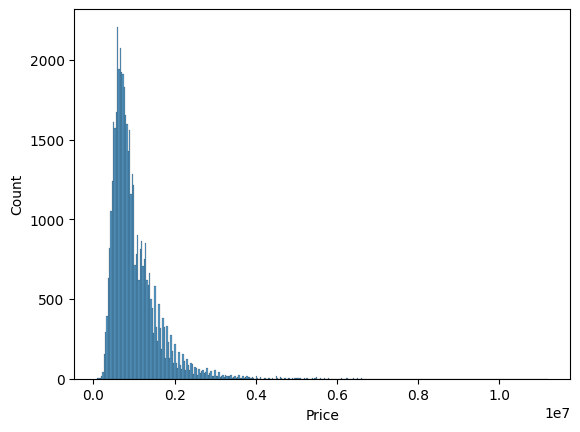

In [19]:
# Quick histplot
sns.histplot(df['Price'])

**Problems?**
- small chart, too many bins (grouped data, interval)
- no title
- unclear x-axis labels, interval

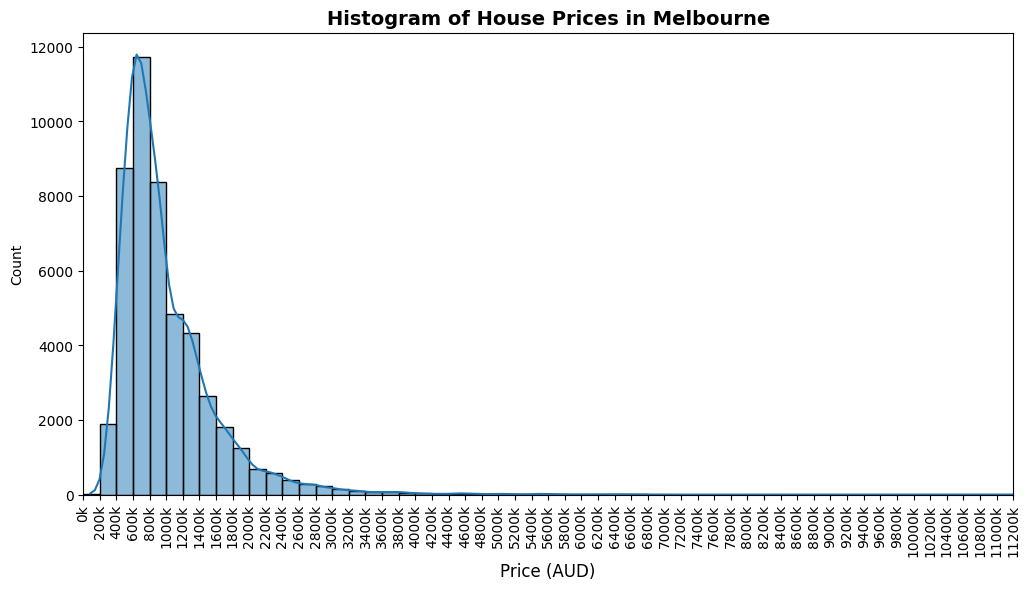

In [54]:
# Create a professional histogram of house prices with clearly labeled x-axis
plt.figure(figsize=(12, 6))

# Define bin edges starting from 0 in 200k increments
bin_edges = range(0, int(df['Price'].max()) + 200000, 200000)

# Plot the histogram with defined bins
sns.histplot(data=df, x="Price", bins=bin_edges, kde=True)

# Set title and labels
plt.title("Histogram of House Prices in Melbourne", fontsize=14, fontweight='bold')
plt.xlabel("Price (AUD)", fontsize=12)
plt.margins(x=0)

# Format x-axis labels as '0', '200k', '400k', etc.
plt.xticks(bin_edges, [f"{int(x/1000)}k" for x in bin_edges], rotation=90)

# Show the plot
plt.show()


<Axes: xlabel='Price'>

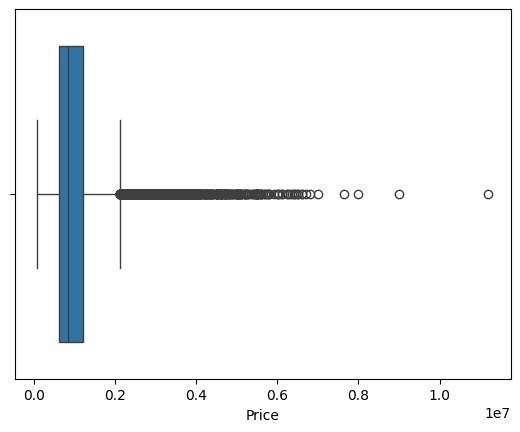

In [21]:
# Quick horizontal boxplot
sns.boxplot(data=df, x='Price')

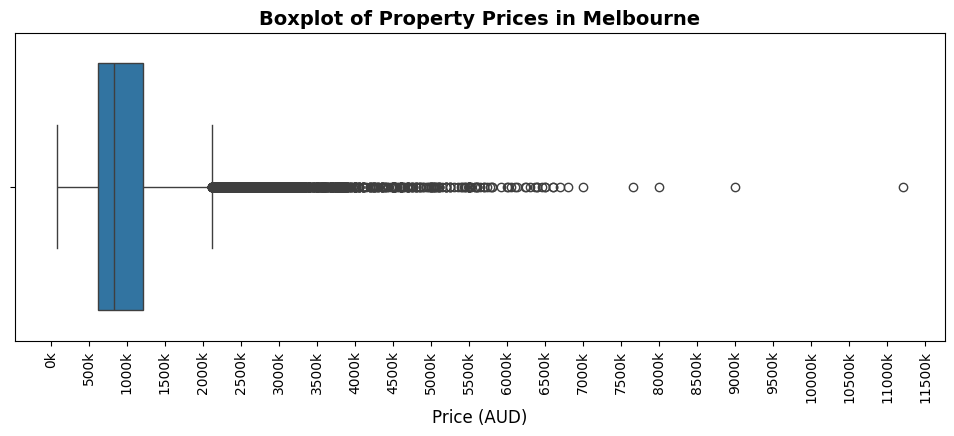

In [22]:
# Create a professional horizontal boxplot for 'Price' with k-format x-axis
plt.figure(figsize=(12, 4))

# Plot the boxplot
sns.boxplot(data=df, x='Price')

# Set title and labels
plt.title("Boxplot of Property Prices in Melbourne", fontsize=14, fontweight='bold')
plt.xlabel("Price (AUD)", fontsize=12)

# Format x-axis labels in 'k' notation (e.g., 500k instead of 500000)
plt.xticks(ticks=range(0, int(df['Price'].max()) + 500000, 500000),
           labels=[f"{int(x/1000)}k" for x in range(0, int(df['Price'].max()) + 500000, 500000)],
           rotation=90)

# Show the plot
plt.show()


<Axes: ylabel='Price'>

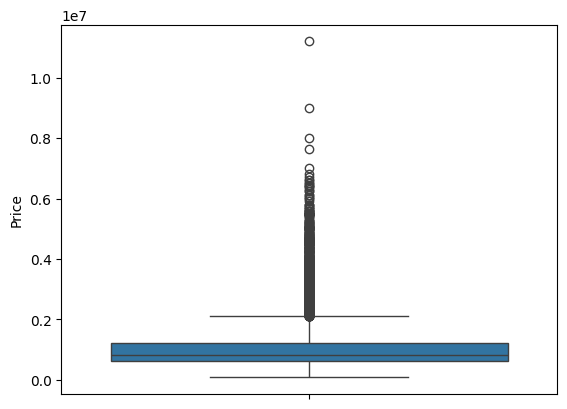

In [23]:
# Quick vertical boxplot
sns.boxplot(data=df, y='Price')

<Axes: xlabel='Rooms', ylabel='Count'>

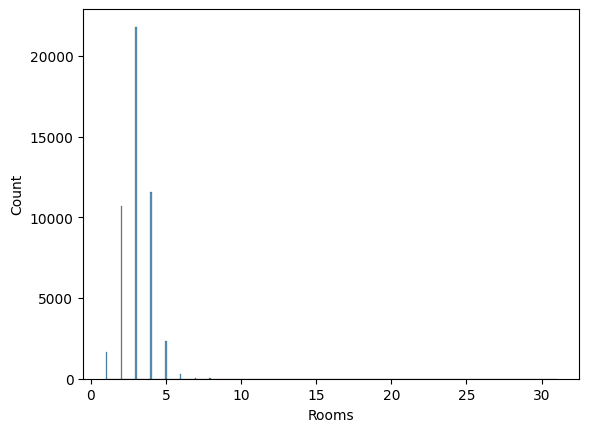

In [24]:
sns.histplot(data=df, x="Rooms")

Histogram may not be appropriate. `Rooms` should be a categorical/discrete variable rather than continuous. A barplot visualization is more appropriate.

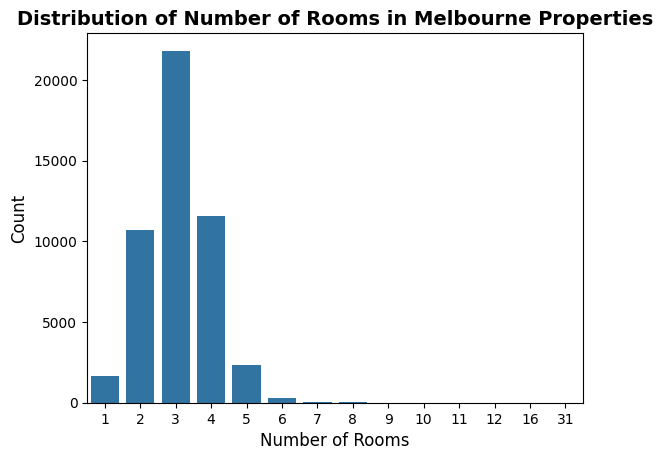

In [25]:
sns.countplot(data=df, x="Rooms")
# Set title and labels
plt.title("Distribution of Number of Rooms in Melbourne Properties", fontsize=14, fontweight='bold')
plt.xlabel("Number of Rooms", fontsize=12)
plt.ylabel("Count", fontsize=12)

# Show the plot
plt.show()


<Axes: xlabel='Distance', ylabel='Count'>

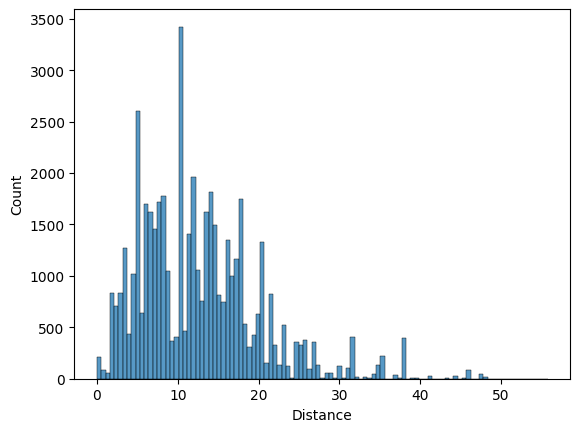

In [26]:
sns.histplot(data=df, x="Distance")

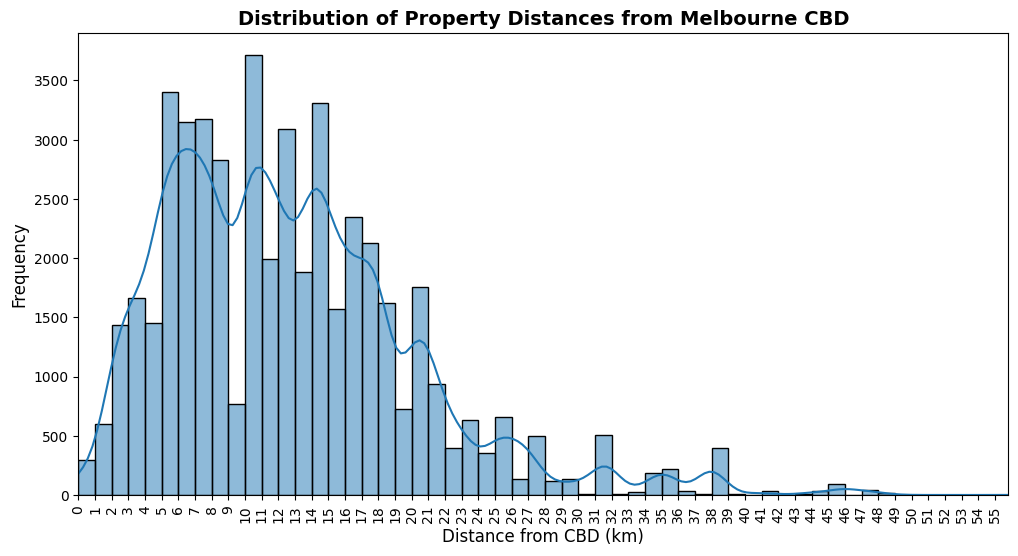

In [55]:
# Create a professional histogram for 'Distance' from CBD
plt.figure(figsize=(12, 6))

# Define appropriate bin size for better visualization
bin_edges = range(0, int(df['Distance'].max()) + 1, 1)  # Bins in 1 km increments

# Plot the histogram
sns.histplot(data=df, x="Distance", bins=bin_edges, kde=True)

# Set title and labels
plt.title("Distribution of Property Distances from Melbourne CBD", fontsize=14, fontweight='bold')
plt.xlabel("Distance from CBD (km)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.margins(x=0)

# Format x-axis ticks in 1 km increments
plt.xticks(bin_edges, rotation=90)

# Improve aesthetics
plt.grid(False)
plt.show()


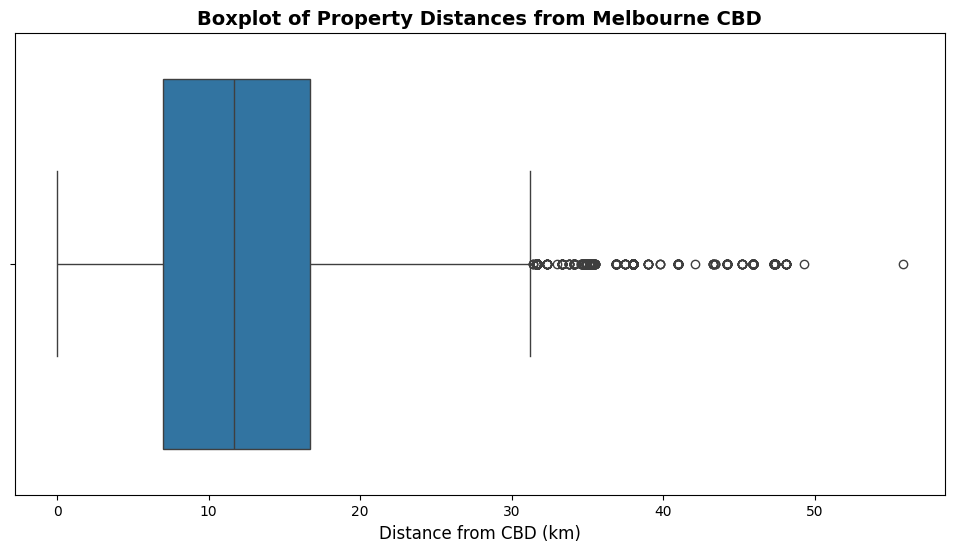

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(x=df["Distance"])

# Set title and labels
plt.title("Boxplot of Property Distances from Melbourne CBD", fontsize=14, fontweight='bold')
plt.xlabel("Distance from CBD (km)", fontsize=12)

# Improve aesthetics
plt.grid(False)
plt.show()


### ⚠️ Handle Outliers with Caution

**Outliers** are extreme values that differ from other observations. They may indicate data errors, rare events, or genuine variability. Mishandling outliers can distort analysis and lead to misleading conclusions.

**How to handle them:**

* **Investigate**: First, verify whether the outlier is a data entry error, a valid rare case, or a structural issue.
* **Options**:
  * **Acknowledge and retain**: If the outlier is a legitimate and meaningful part of the data (e.g. a true high-value customer; luxury house/car with high price tag), keep it. *Important: may reflect valuable business insight.*
  * **Remove**: Exclude only if the value is clearly erroneous or irrelevant. *Risk: may reduce sample size or hide meaningful variation.*
  * **Cap (Winsorise)**: Replace extreme values with a specified percentile (e.g. 1st and 99th). *Balances impact while retaining data structure.*
  * **Transform**: Apply a log, square root, or z-score to reduce skew. *Preserves data but alters interpretability.*

**Tip**: Always document your decision and consider the business and statistical implications of modifying outliers.

Identify outliers using IQR methods

In [29]:
# IQR methods
# Compute IQR
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = df[(df['Price'] < lower_bound) | (df['Price'] > upper_bound)]

# Display the number of outliers detected
num_outliers = outliers.shape[0]

# Show the summary and a few outliers
print(f'Any price < ${lower_bound} or price > ${upper_bound} are identified as outliers')
print(f'Number of outliers in Price column: {num_outliers}')
print('Some sample outliers')
outliers

Any price < $-280000.0 or price > $2120000.0 are identified as outliers
Number of outliers in Price column: 2272
Some sample outliers


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Postcode,Regionname,Propertycount,Distance,CouncilArea
33,Balwyn,9 Kenilworth St,5,h,2700000.00,PI,hockingstuart,2017-04-01,3103,Southern Metropolitan,5682,7.90,Boroondara City Council
39,Balwyn North,203 Belmore Rd,4,h,2600000.00,VB,Jellis,2017-04-01,3104,Southern Metropolitan,7809,9.70,Boroondara City Council
41,Balwyn North,9 Cumberland Av,4,h,2470000.00,PI,Fletchers,2017-04-01,3104,Southern Metropolitan,7809,9.70,Boroondara City Council
63,Black Rock,38 Ardoyne St,4,h,3000000.00,S,Buxton,2017-04-01,3193,Southern Metropolitan,2866,17.30,Bayside City Council
82,Brighton,435 New St,4,h,2250000.00,VB,Buxton,2017-04-01,3186,Southern Metropolitan,10579,10.50,Bayside City Council
...,...,...,...,...,...,...,...,...,...,...,...,...,...
62748,Mount Waverley,31 The Highway,5,h,2700000.00,VB,Jellis,2017-12-30,3149,Eastern Metropolitan,13366,14.20,Monash City Council
62776,Northcote,18 Thames St,5,h,2525000.00,SP,Jellis,2017-12-30,3070,Northern Metropolitan,11364,5.30,Darebin City Council
62811,Prahran,7 Trinian St,3,h,2400000.00,VB,Marshall,2017-12-30,3181,Southern Metropolitan,7717,4.60,Stonnington City Council
62951,Toorak,2 Cross St,5,h,4515000.00,PI,Kay,2017-12-30,3142,Southern Metropolitan,7217,4.10,Stonnington City Council


Handles outliers

In [30]:
# Option 1: Remove outliers
df_no_outliers = df[(df['Price'] >= lower_bound) & (df['Price'] <= upper_bound)]

In [31]:
# Option 2: Cap outliers
df_capped = df.copy()
df_capped['Price'] = np.where(df_capped['Price'] < lower_bound, lower_bound, df_capped['Price'])
df_capped['Price'] = np.where(df_capped['Price'] > upper_bound, upper_bound, df_capped['Price'])

In [32]:
# Option 3: Log Transformation (for skewed distributions)
df_transformed = df.copy()
df_transformed['Price'] = np.log1p(df_transformed['Price'])  # log(Price + 1) to handle zero values

In [33]:
# Display results
print(f"Original dataset size: {df.shape[0]}")
print(f"After removing outliers: {df_no_outliers.shape[0]}")
print(f"Example of capped prices:\n{df_capped[['Price']].head()}")
print(f"Example of log-transformed prices:\n{df_transformed[['Price']].head()}")

Original dataset size: 48433
After removing outliers: 46161
Example of capped prices:
       Price
0 1490000.00
1 1220000.00
2 1420000.00
3 1515000.00
4  670000.00
Example of log-transformed prices:
   Price
0  14.21
1  14.01
2  14.17
3  14.23
4  13.42


**Remove outliers**

<Axes: xlabel='Price', ylabel='Count'>

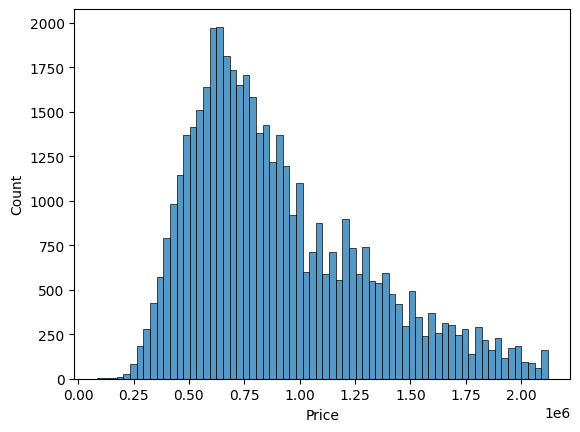

In [34]:
sns.histplot(df_no_outliers['Price'])

<Axes: ylabel='Price'>

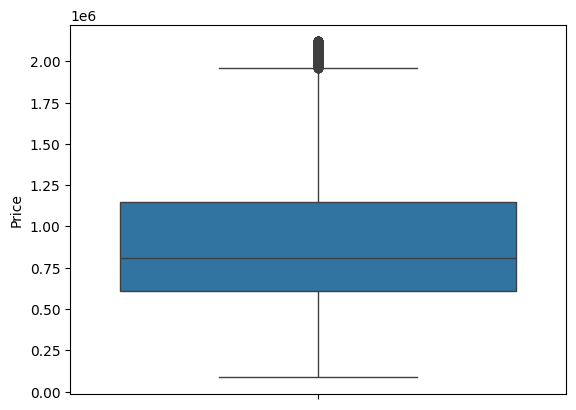

In [35]:
sns.boxplot(df_no_outliers['Price'])

**Capped outliers**

<Axes: xlabel='Price', ylabel='Count'>

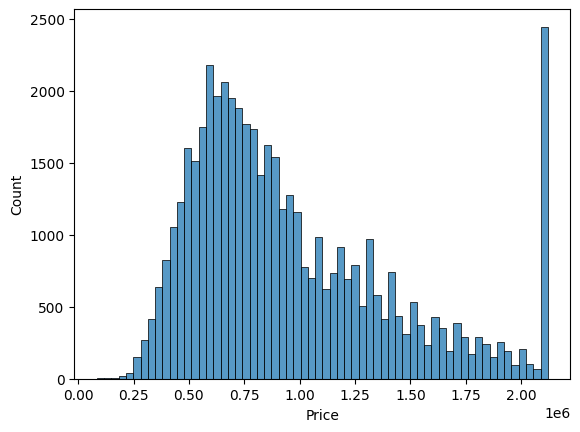

In [36]:
sns.histplot(df_capped['Price'])

<Axes: ylabel='Price'>

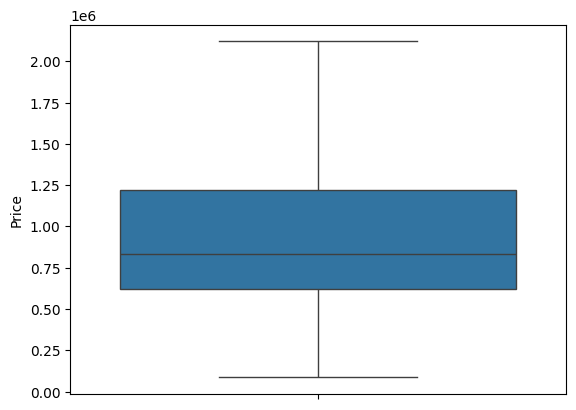

In [37]:
sns.boxplot(df_capped['Price'])

**Transform outliers**

<Axes: xlabel='Price', ylabel='Count'>

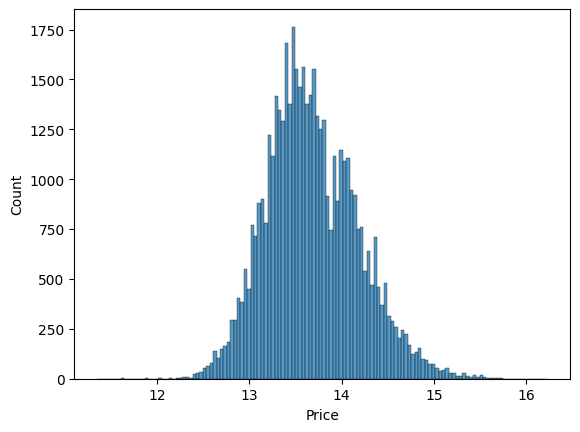

In [38]:
sns.histplot(df_transformed['Price'])

<Axes: ylabel='Price'>

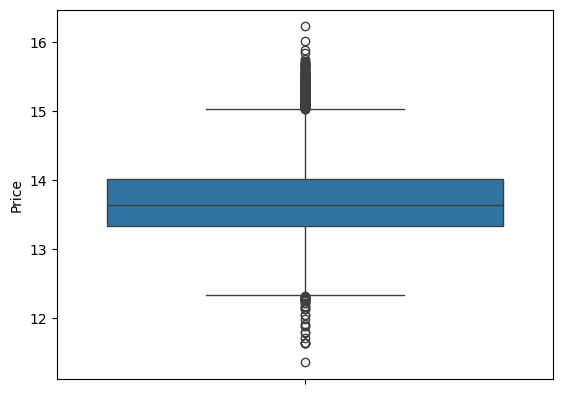

In [39]:
sns.boxplot(df_transformed['Price'])

### **Reporting**


*   What are the central tendency, key data points, variability, and distribution shape of this variable?
*   How do you interpret the distribution?
*   Did you identify and address outliers? How and Why?
*   What business insights can you derive from this analysis?



1. The central tendency (mean, median), key data points (min, max, quartiles), and variability (standard deviation, IQR) for the 'Price' variable from the df.describe() output.



2. Interpretation of 'Price' Distribution

Histogram Analysis (referencing cell `yhjrdPtemWCm`):**

The histogram of 'Price' reveals a clear right-skewed distribution. The majority of properties are concentrated in the lower price ranges, with a significant peak observed between \$400k and \$800k. As prices increase, the frequency of properties sharply declines, indicating that very expensive properties are much less common. This suggests that the average property price is likely pulled up by a smaller number of high-value homes.

Box Plot Analysis (referencing cell `kRImUnm5s7kd`):**

The box plot corroborates the right-skewed nature of the 'Price' distribution. The median (the line inside the box) is positioned closer to the first quartile (25th percentile) than to the third quartile (75th percentile), which is characteristic of a positively skewed distribution. The right whisker is considerably longer than the left whisker, further indicating a spread of higher prices. A large number of individual data points extend far beyond the upper whisker, confirming the presence of numerous high-value outliers. These outliers represent properties with exceptionally high prices, significantly above the typical market range.

Overall Distribution Shape and Concentration:**

Based on both visualizations, the 'Price' variable exhibits a strong positive (right) skew. The data is heavily concentrated at the lower end of the price spectrum, with most houses priced under \$1.2 million. While the median price is \$830,000, the mean price is \$997,898.24, which is higher due to the influence of the long tail of expensive properties. This concentration suggests a competitive market for moderately priced homes, with fewer buyers in the luxury segment. The presence of significant outliers indicates a segment of the market with exceptionally high-value properties.

3. Outliers are identified using methods like the Interquartile Range (IQR) method to understand extreme values in the data. Handling them is crucial because they can significantly distort statistical analyses and model performance. The choice of handling method depends on the nature of the outlier and the analytical goal.

4. Can helps market concentration and affordability, high-end market and investment opportunities, market dynamics and strategy.

## Categorical variables

### Categorical variables summary

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48433 entries, 0 to 63020
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Suburb         48433 non-null  object        
 1   Address        48433 non-null  object        
 2   Rooms          48433 non-null  int64         
 3   Type           48433 non-null  object        
 4   Price          48433 non-null  float64       
 5   Method         48433 non-null  object        
 6   SellerG        48433 non-null  object        
 7   Date           48433 non-null  datetime64[ns]
 8   Postcode       48433 non-null  int64         
 9   Regionname     48433 non-null  object        
 10  Propertycount  48433 non-null  int64         
 11  Distance       48433 non-null  float64       
 12  CouncilArea    48433 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(3), object(7)
memory usage: 5.2+ MB


In [42]:
# Define your categorical columns here
categorical_cols = ['Suburb', 'Rooms', 'Type', 'Method', 'SellerG', 'Regionname', 'Postcode', 'CouncilArea']
df[categorical_cols] = df[categorical_cols].astype('category')

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48433 entries, 0 to 63020
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Suburb         48433 non-null  category      
 1   Address        48433 non-null  object        
 2   Rooms          48433 non-null  category      
 3   Type           48433 non-null  category      
 4   Price          48433 non-null  float64       
 5   Method         48433 non-null  category      
 6   SellerG        48433 non-null  category      
 7   Date           48433 non-null  datetime64[ns]
 8   Postcode       48433 non-null  category      
 9   Regionname     48433 non-null  category      
 10  Propertycount  48433 non-null  int64         
 11  Distance       48433 non-null  float64       
 12  CouncilArea    48433 non-null  category      
dtypes: category(8), datetime64[ns](1), float64(2), int64(1), object(1)
memory usage: 2.8+ MB


/tmp/ipython-input-2040116641.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[categorical_cols] = df[categorical_cols].astype('category')


In [43]:
df.describe(include='category')

,Suburb,Rooms,Type,Method,SellerG,Postcode,Regionname,CouncilArea
count,48433,48433,48433,48433,48433,48433,48433,48433
unique,370,14,3,5,422,221,8,34
top,Reservoir,3,h,S,Barry,3073,Northern Metropolitan,Darebin City Council
freq,1067,21812,34161,30624,4818,1067,13598,3462


### Frequency distributions

**`Type` example**

In [44]:
# Count occurrences of each property type
df['Type'].value_counts()

,count
Type,
h,34161
u,9292
t,4980


In [45]:
# Compute relative frequency of each property type
df['Type'].value_counts(normalize=True)

,proportion
Type,
h,0.71
u,0.19
t,0.10


### Visualise categorical data

#### Bar chart (preferred)

<Axes: xlabel='Type', ylabel='count'>

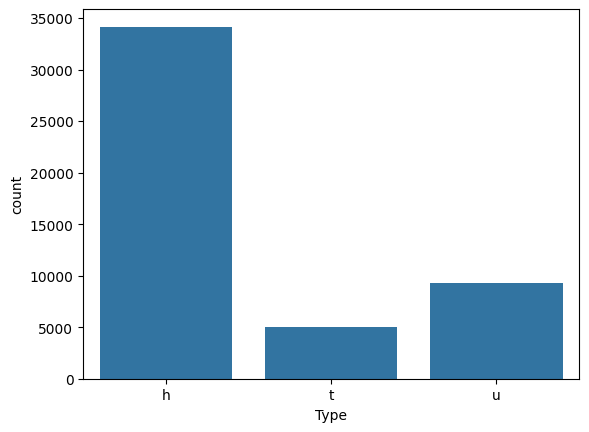

In [46]:
sns.countplot(data=df, x="Type")

<Axes: xlabel='count', ylabel='Type'>

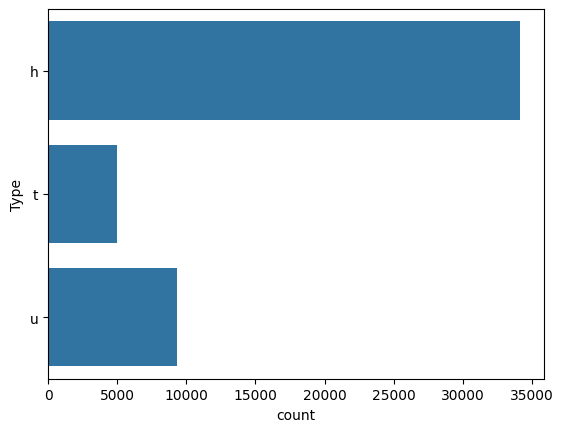

In [47]:
sns.countplot(data=df, y="Type")

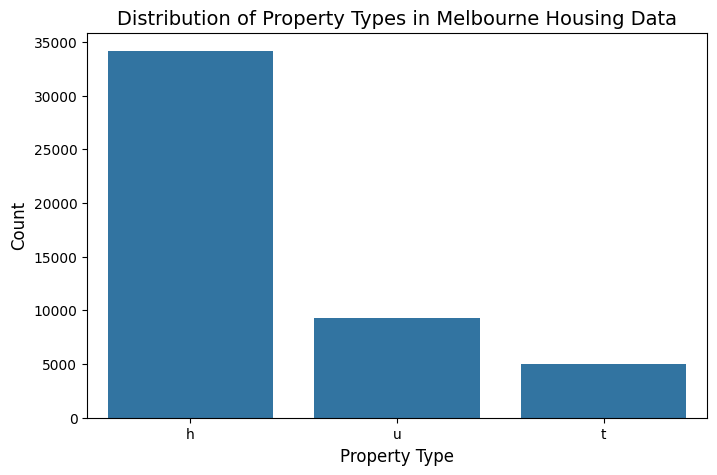

In [48]:
# Set the figure size
plt.figure(figsize=(8, 5))

# Create a count plot for property type distribution
sns.countplot(data=df, x="Type", order=df["Type"].value_counts().index)

# Add labels and title
plt.xlabel("Property Type", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.title("Distribution of Property Types in Melbourne Housing Data", fontsize=14)

# Display the plot
plt.show()

#### Pie chart (Be careful!)

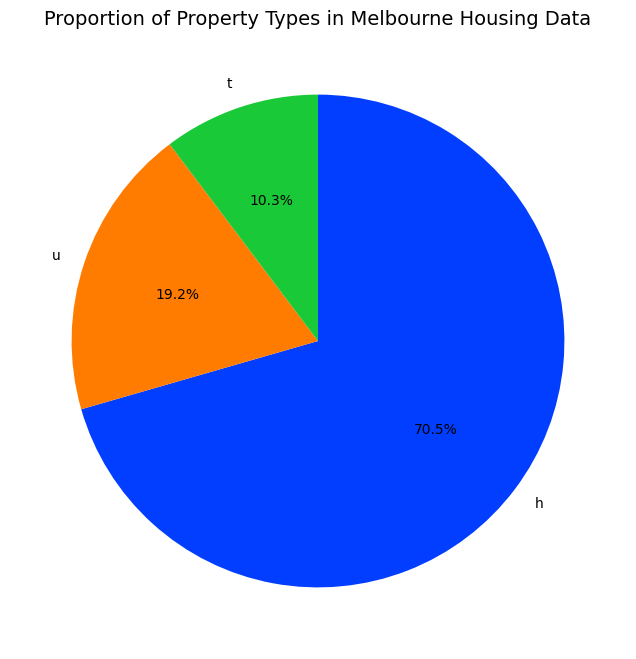

In [49]:
# Create a pie chart with sorted slices, starting at 12 o'clock (90 degrees) and in a clockwise direction
plt.figure(figsize=(8, 8))
type_counts_sorted = df['Type'].value_counts().sort_values(ascending=False)

plt.pie(type_counts_sorted, labels=type_counts_sorted.index, autopct='%1.1f%%',
        colors=sns.color_palette("bright"), startangle=90, counterclock=False)

# Add title
plt.title("Proportion of Property Types in Melbourne Housing Data", fontsize=14)

# Display the plot
plt.show()


### **Reporting**

*   What are the frequency and mode in this distribution?
*   How do you interpret the distribution?
*   What business insights can you derive from this analysis?

1. The frequency and mode for the categorical variables in your dataset are provided in the outputs of the previous cells. The df.describe(include='category') output directly shows the 'top' (mode) and 'freq' (frequency of the mode) for each categorical column. The value_counts() output for each column provides the full frequency distribution for all unique categories within that variable.

In [52]:
df.describe(include='category')

,Suburb,Rooms,Type,Method,SellerG,Postcode,Regionname,CouncilArea
count,48433,48433,48433,48433,48433,48433,48433,48433
unique,370,14,3,5,422,221,8,34
top,Reservoir,3,h,S,Barry,3073,Northern Metropolitan,Darebin City Council
freq,1067,21812,34161,30624,4818,1067,13598,3462


2 & 3 Interpreting the Distribution of Categorical Variables and Business Insights

Based on the frequency distributions and count plots for categorical variables, we can derive several insights:

1. Property Type (`Type`)
*   **Distribution**: Houses ('h') are by far the most dominant property type, making up approximately 71% of the dataset. Units ('u') are the second most common (19%), followed by Townhouses ('t') (10%).
*   **Business Insight**: This indicates a strong market preference or supply for traditional houses in Melbourne. Real estate developers and investors might focus on house development or renovation, while marketers should tailor campaigns recognizing the primary demand for 'h' type properties. There could be niche opportunities in the unit and townhouse markets for specific demographics or locations.

 2. Number of Rooms (`Rooms`)
*   **Distribution**: The most frequent number of rooms is 3 (with 21,812 properties), followed by 4 rooms (11,576) and 2 rooms (10,674). Properties with 1, 5, or more rooms are significantly less common.
*   **Business Insight**: The market is primarily composed of mid-sized properties (2-4 rooms). This suggests a strong demand from small to medium-sized families or individuals. Real estate agents can emphasize properties within this room count range, and construction companies might prioritize building homes with 2, 3, or 4 rooms to align with market demand.

 3. Sale Method (`Method`)
*   **Distribution**: The 'S' (Sold) method is overwhelmingly the most common (30,624 properties), indicating that most properties are sold through standard sale procedures. Other methods like 'SP' (Sold Prior), 'PI' (Passed In), and 'VB' (Vendor Bid) are considerably less frequent.
*   **Business Insight**: Standard sales processes are the norm. Real estate agencies should optimize their strategies for traditional selling methods. While less common, understanding the dynamics of 'Sold Prior' or 'Passed In' properties can offer insights into market competitiveness and seller expectations.

 4. Seller Group (`SellerG`)
*   **Distribution**: 'Barry', 'Jellis', and 'Nelson' are the top three real estate agencies by transaction volume. There's a long tail of many agencies with fewer sales.
*   **Business Insight**: These top agencies hold significant market share. New agencies might find it challenging to compete in terms of volume and could benefit from specializing in specific niches (e.g., luxury, specific suburbs) or offering unique value propositions. Property owners looking to sell might consider these top agencies for their broader reach and experience.

 5. Region Name (`Regionname`)
*   **Distribution**: 'Northern Metropolitan' (13,598 properties) and 'Southern Metropolitan' (12,549 properties) are the most active regions, followed by 'Western Metropolitan' (9,680 properties).
*   **Business Insight**: These regions represent the primary hubs of real estate activity in Melbourne. Investors and developers might find more opportunities and liquidity in these areas. For buyers, understanding the regional distribution can help in targeting areas that match their preferences for urban living or proximity to amenities.

 6. Council Area (`CouncilArea`)
*   **Distribution**: 'Darebin City Council' (3,462 properties) and 'Boroondara City Council' (3,455 properties) show the highest activity. Similar to 'Regionname', there's a variation across different council areas.
*   **Business Insight**: Council areas with higher property counts indicate areas of high development, population growth, or frequent transactions. This information is crucial for local policy-making, infrastructure planning, and for businesses offering local services (e.g., maintenance, renovations).

 7. Suburb (`Suburb`) and Postcode (`Postcode`)
*   **Distribution**: These variables are highly granular, with 'Reservoir' (1067 properties) and '3073' (1067 properties) being the most frequent for suburb and postcode respectively. Both show a diverse range with many unique locations having fewer transactions.
*   **Business Insight**: The high number of unique suburbs and postcodes highlights the diversity of the Melbourne housing market. While some areas are very active, there are many smaller, less active markets. Local market analysis is critical for hyper-local businesses and for buyers seeking specific community characteristics.

In [53]:
# Display summary statistics for categorical variables
print("Categorical Variable Summary:")
for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts())
    print("-" * 39)

Categorical Variable Summary:

Column: Suburb
Suburb
Reservoir           1067
Bentleigh East       696
Richmond             642
Craigieburn          598
Preston              593
                    ... 
Belgrave               1
Warneet                1
Warrandyte South       1
croydon                1
viewbank               1
Name: count, Length: 370, dtype: int64
---------------------------------------

Column: Rooms
Rooms
3     21812
4     11576
2     10674
5      2350
1      1670
6       283
7        36
8        19
10        6
9         2
12        2
11        1
16        1
31        1
Name: count, dtype: int64
---------------------------------------

Column: Type
Type
h    34161
u     9292
t     4980
Name: count, dtype: int64
---------------------------------------

Column: Method
Method
S     30624
SP     6480
PI     5940
VB     5024
SA      365
Name: count, dtype: int64
---------------------------------------

Column: SellerG
SellerG
Barry            4818
Jellis           4088
Ne

### Lazy EDA for all categorical stats and visualisation

In [50]:
# Display summary statistics for categorical variables
print("Categorical Variable Summary:")
for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts())
    print("-" * 39)

Categorical Variable Summary:

Column: Suburb
Suburb
Reservoir           1067
Bentleigh East       696
Richmond             642
Craigieburn          598
Preston              593
                    ... 
Belgrave               1
Warneet                1
Warrandyte South       1
croydon                1
viewbank               1
Name: count, Length: 370, dtype: int64
---------------------------------------

Column: Rooms
Rooms
3     21812
4     11576
2     10674
5      2350
1      1670
6       283
7        36
8        19
10        6
9         2
12        2
11        1
16        1
31        1
Name: count, dtype: int64
---------------------------------------

Column: Type
Type
h    34161
u     9292
t     4980
Name: count, dtype: int64
---------------------------------------

Column: Method
Method
S     30624
SP     6480
PI     5940
VB     5024
SA      365
Name: count, dtype: int64
---------------------------------------

Column: SellerG
SellerG
Barry            4818
Jellis           4088
Ne

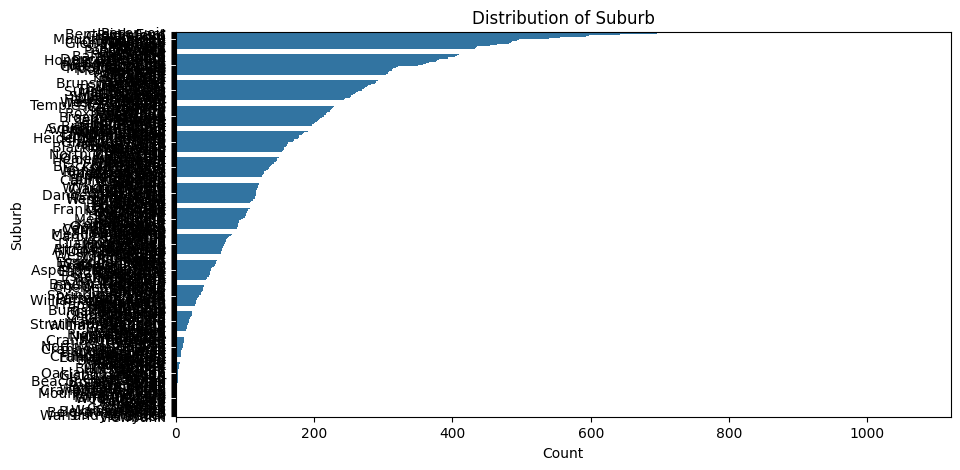

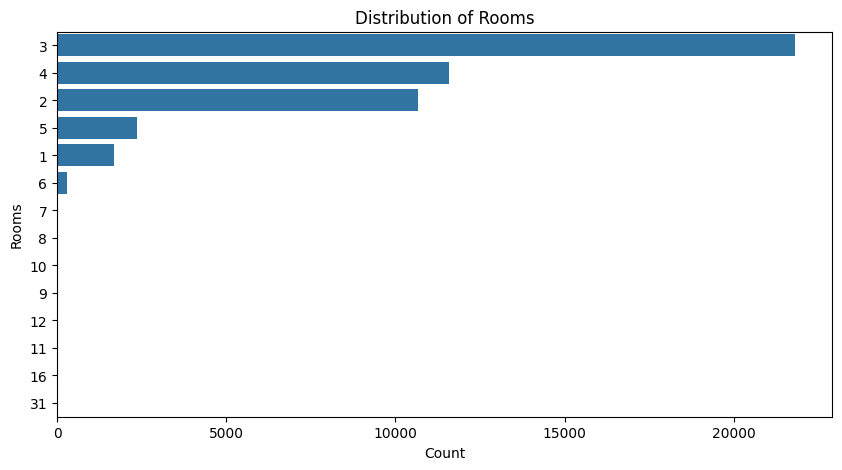

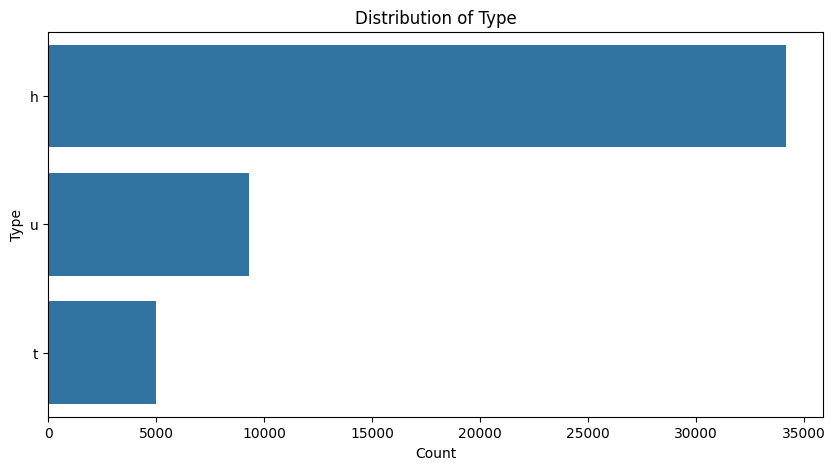

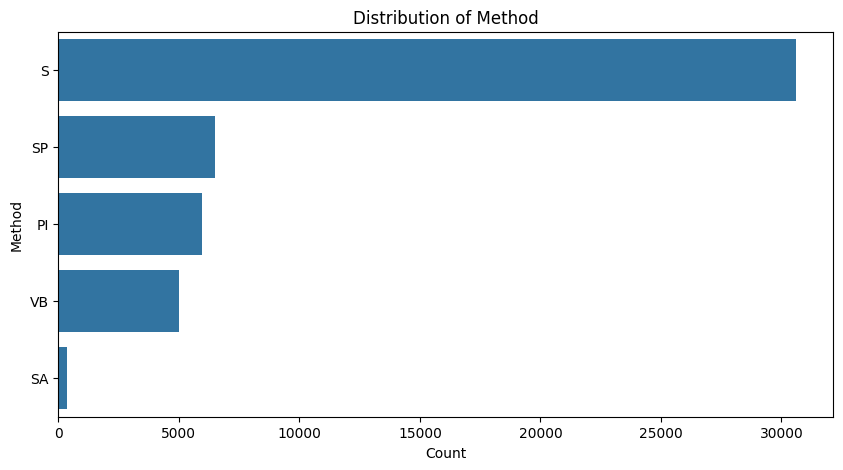

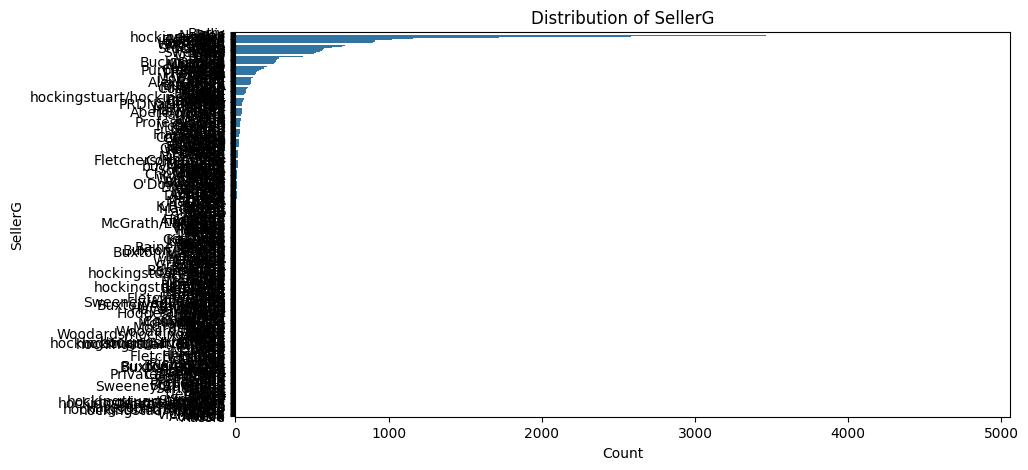

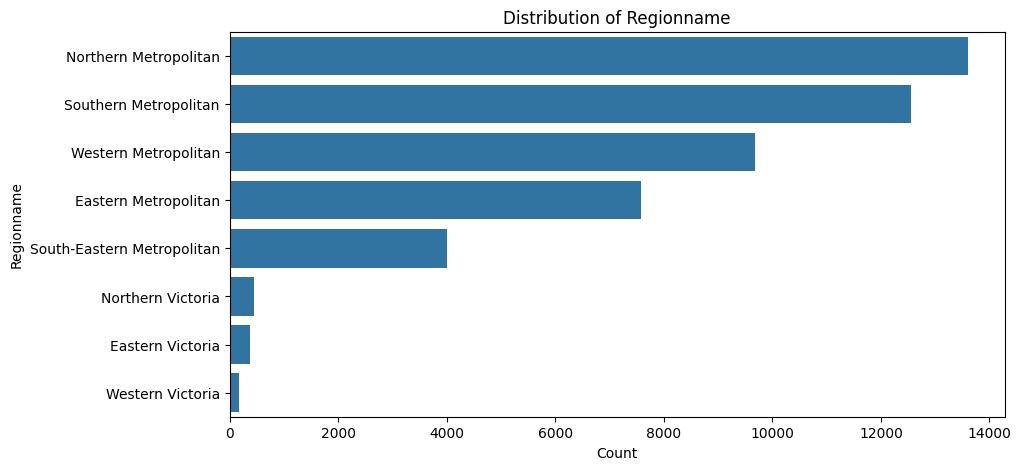

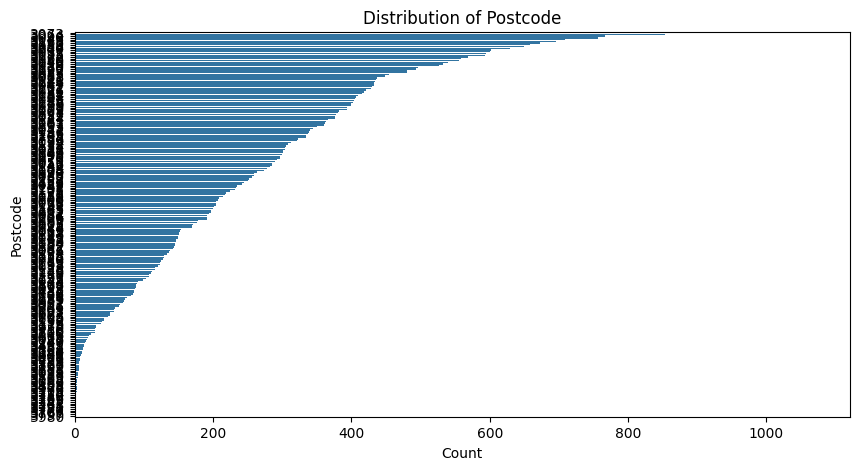

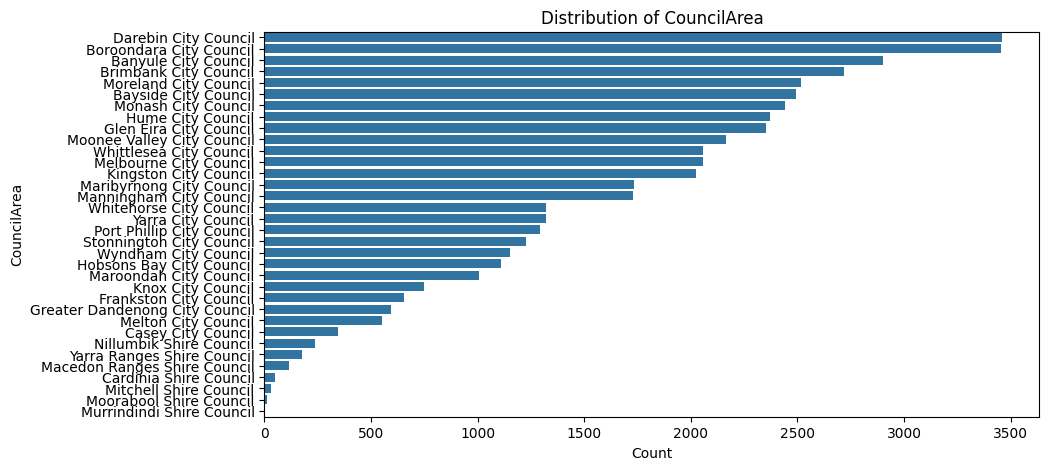

In [51]:
# Visualizing categorical distributions
for col in categorical_cols:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, y=col, order=df[col].value_counts().index,)
    plt.xlabel("Count")
    plt.ylabel(col)
    plt.title(f"Distribution of {col}")
    plt.show()

# Homework: Apply What You Learned!

1. Load a different dataset (e.g., assignment_data.csv).
2. Perform data inspection, cleaning, and transformation.
3. Conduct univariate and bivariate analyses for your Assignment 1
